## Data Collection and Loading

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
df = pd.read_csv('../data/raw/telco-customer.csv')

## Basic Data Inspection & Overview

In [131]:
df.shape

(7043, 21)

In [132]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [133]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [135]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**Dataset Description (Telco Customer Churn)**

- customerID: รหัสประจำตัวลูกค้าแต่ละราย ใช้ระบุตัวตนของลูกค้า (Unique ID)
- gender: เพศของลูกค้า (Male, Female)
- SeniorCitizen: ลูกค้าเป็นผู้สูงอายุหรือไม่ (`1` = ใช่, `0` = ไม่ใช่)
- Partner: ลูกค้ามีคู่สมรสหรือคู่ชีวิตหรือไม่ (`Yes` = มี, `No` = ไม่มี)
- Dependents: ลูกค้ามีผู้ที่ต้องดูแล (บุตรหรือสมาชิกในครอบครัว) หรือไม่ (`Yes` = มี, `No` = ไม่มี)
- tenure: ระยะเวลาที่ลูกค้าใช้บริการกับบริษัท (หน่วยเป็นเดือน)
- PhoneService: ลูกค้าใช้บริการโทรศัพท์หรือไม่ (`Yes` = ใช้, No` = ไม่ใช้)
- MultipleLines: ลูกค้ามีหมายเลขโทรศัพท์หลายสายหรือไม่ (`Yes` = มีหลายสาย, `No` = มีสายเดียว, `No phone service` = ไม่มีบริการโทรศัพท์)
- InternetService: ประเภทบริการอินเทอร์เน็ตที่ลูกค้าใช้ (`DSL`, `Fiber optic`, `No`)
- OnlineSecurity: มีบริการรักษาความปลอดภัยออนไลน์หรือไม่ (`Yes`, `No`, `No internet service`)
- OnlineBackup: มีบริการสำรองข้อมูลออนไลน์หรือไม่ (`Yes`, `No`, `No internet service`)
- DeviceProtection: มีบริการป้องกันอุปกรณ์หรือไม่ (`Yes`, `No`, `No internet service`)
- TechSupport: มีบริการสนับสนุนทางเทคนิคหรือไม่ (`Yes`, `No`, `No internet service`)
- StreamingTV: มีบริการรับชมทีวีผ่านอินเทอร์เน็ตหรือไม่ (`Yes`, `No`, `No internet service`)
- StreamingMovies: มีบริการรับชมภาพยนตร์ผ่านอินเทอร์เน็ตหรือไม่ (`Yes`, `No`, `No internet service`)
- Contract: ประเภทสัญญาของลูกค้า (`Month-to-month` : รายเดือน, `One year` : รายปี, `Two year` : สองปี)
- PaperlessBilling: ลูกค้าเลือกใช้ใบแจ้งหนี้แบบอิเล็กทรอนิกส์หรือไม่ (`Yes` = ใช้ ,`No` = รับใบแจ้งหนี้แบบกระดาษ)
- PaymentMethod: วิธีการชำระเงิน
    - `Electronic check`
    - `Mailed check`
    - `Bank transfer (automatic)`
    - `Credit card (automatic)`
- MonthlyCharges: ค่าใช้จ่ายรายเดือนของลูกค้า (หน่วยเป็นดอลลาร์)
- TotalCharges: ค่าใช้จ่ายสะสมทั้งหมดตั้งแต่เริ่มใช้บริการจนถึงปัจจุบัน (หน่วยเป็นดอลลาร์)
- Churn (Target Variable): ลูกค้าเลิกใช้บริการหรือไม่ (`Yes` = ลูกค้าเลิกใช้บริการ, `No` = ลูกค้ายังคงใช้บริการ)

## Data Cleaning

### Correct Data Types

In [136]:
df['SeniorCitizen'] = (df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}).astype('category'))

In [137]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]

df[cat_cols] = df[cat_cols].astype('category')

In [138]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [139]:
df.dtypes

customerID               str
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

### Handle Missing Values

In [140]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [141]:
df.dropna(inplace=True)

In [142]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Remove Duplicates

In [143]:
df.duplicated().sum()

np.int64(0)

### Drop Irrelevant Columns

In [144]:
df.drop(columns=['customerID'], inplace=True)

In [145]:
df.dtypes

gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

## Univariate Analysis

### Target Variables

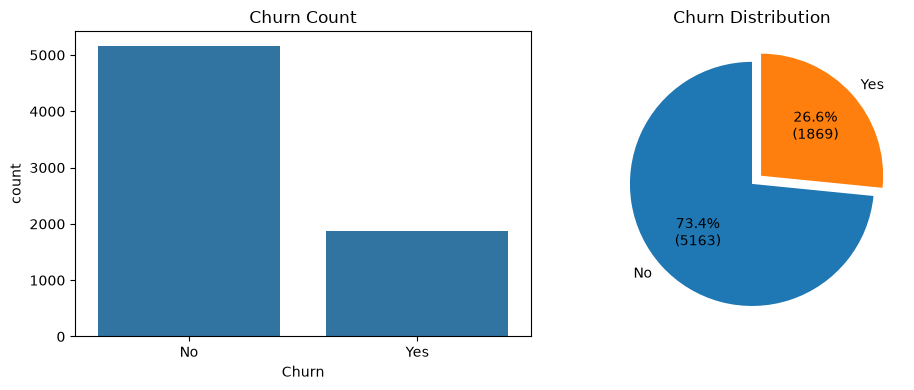

In [146]:
target = 'Churn'
counts = df[target].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x=target, ax=axes[0])
axes[0].set_title('Churn Count')
axes[1].pie(counts, labels=counts.index,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*counts.sum())})',
    startangle=90, explode=(0, 0.1)
)
axes[1].set_title('Churn Distribution')
plt.tight_layout()
plt.savefig('../outputs/figures/target.png', dpi=300, bbox_inches='tight')
plt.show()

### Numerical Variables

In [147]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


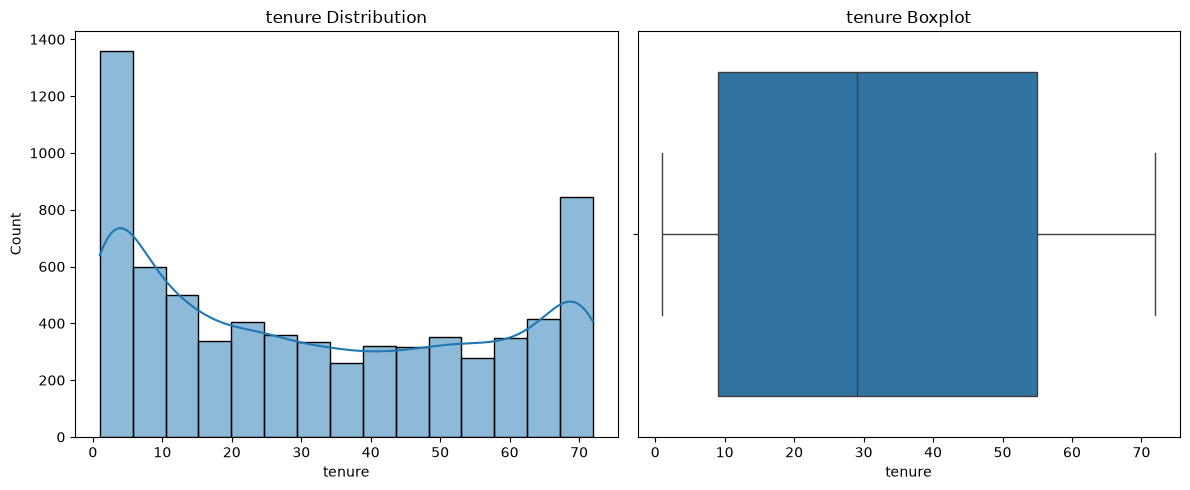

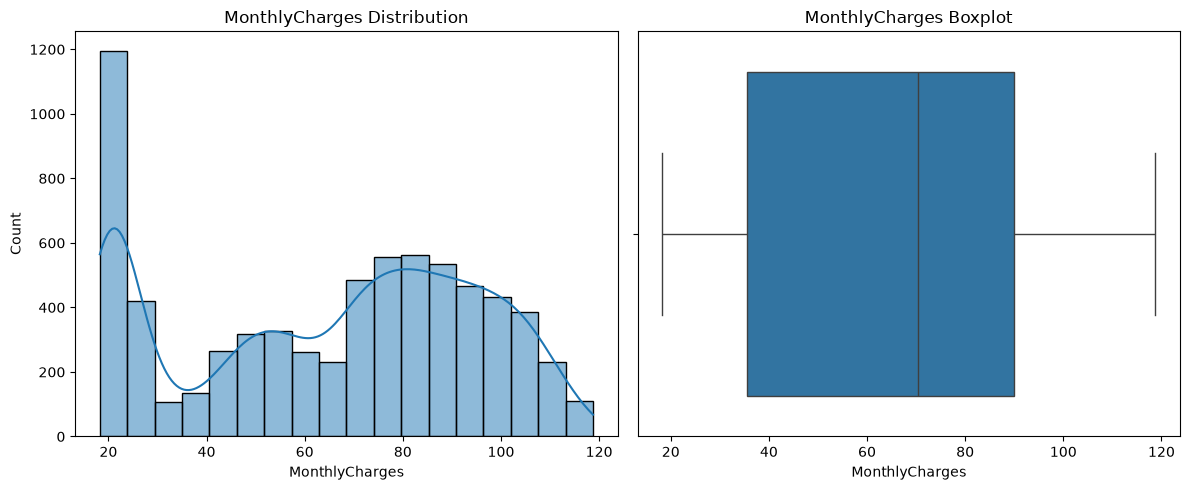

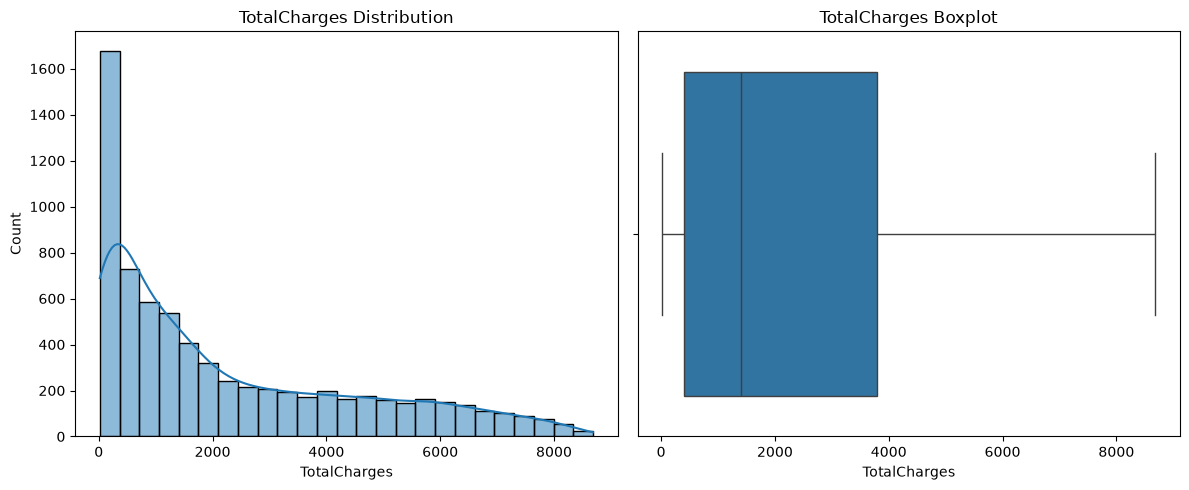

In [148]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')
    plt.tight_layout()
    plt.show()

### Categorical Variables

In [149]:
df.describe(include=['category']).T

,count,unique,top,freq
gender,7032,2,Male,3549
SeniorCitizen,7032,2,No,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094


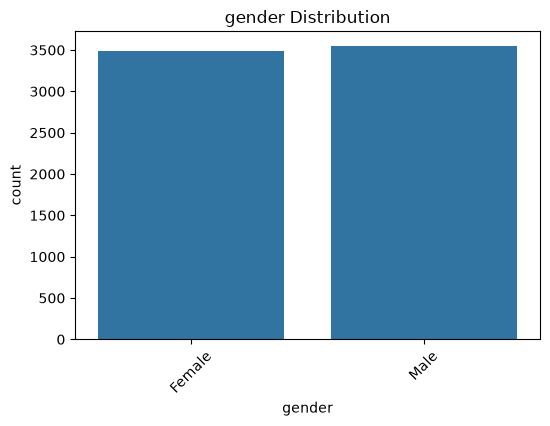

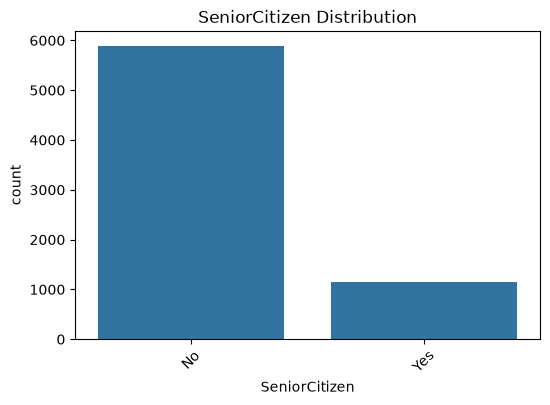

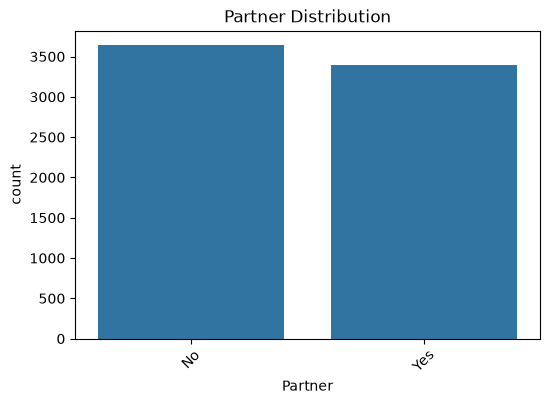

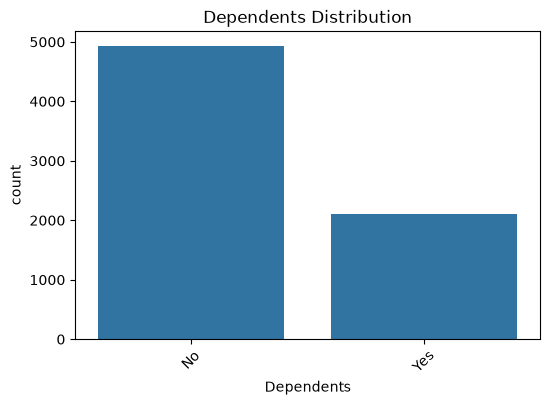

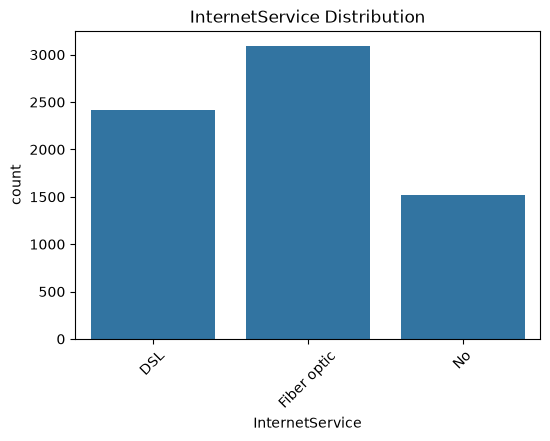

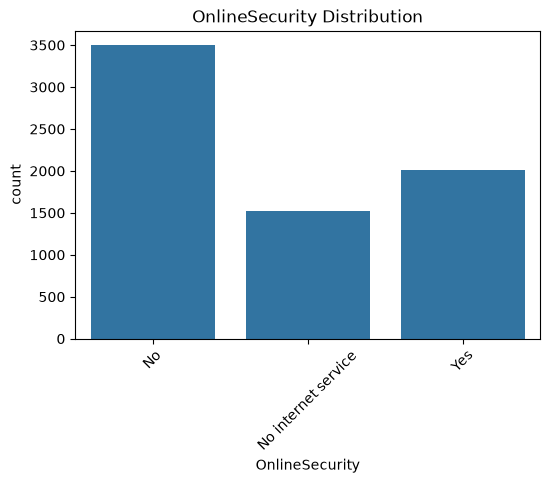

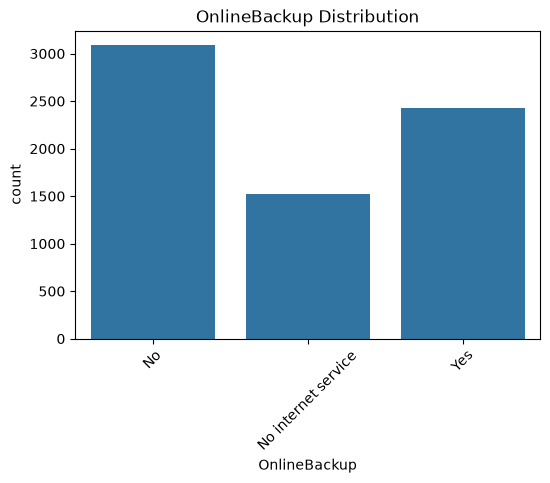

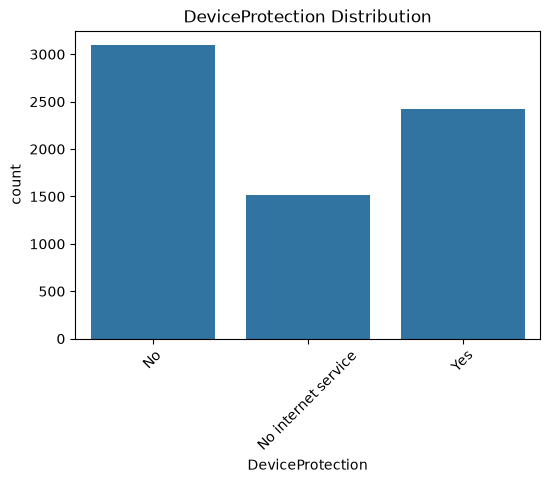

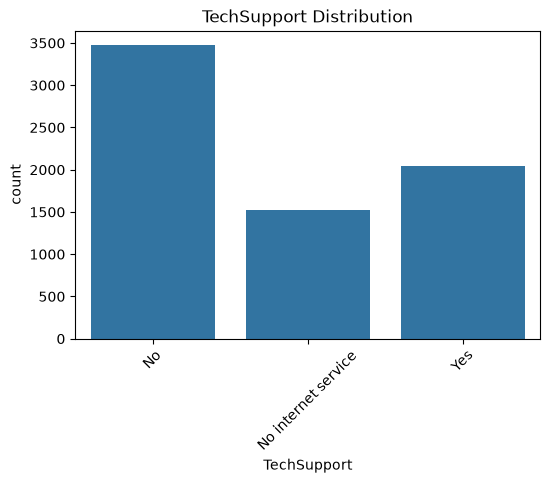

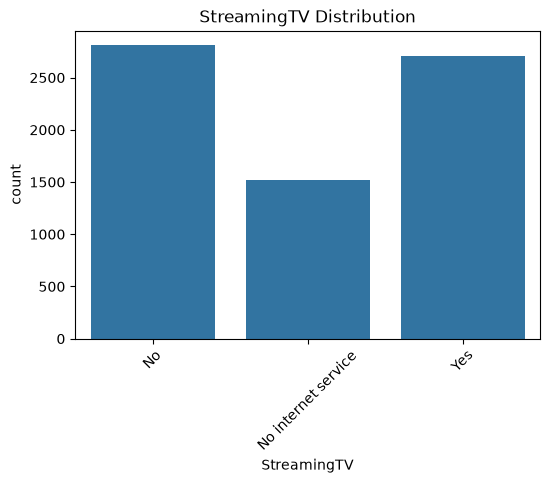

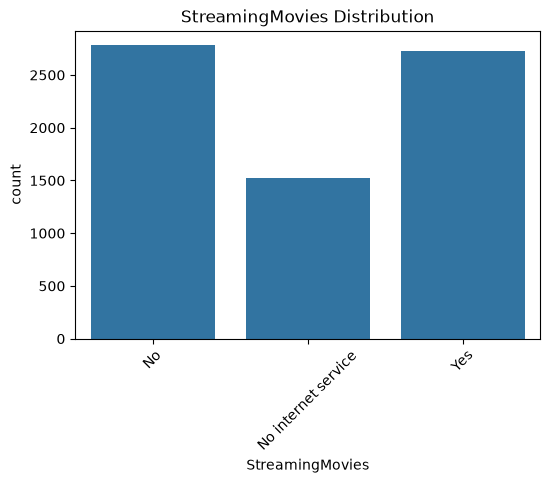

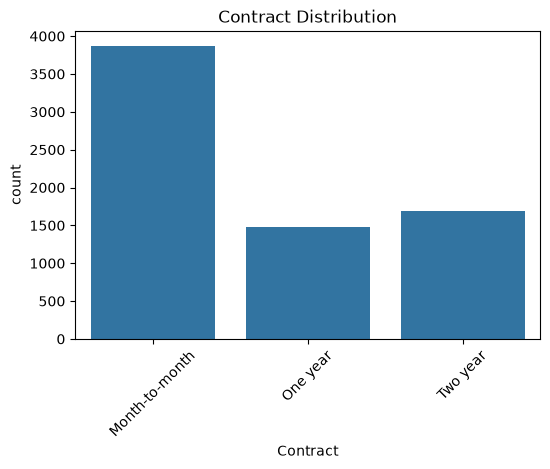

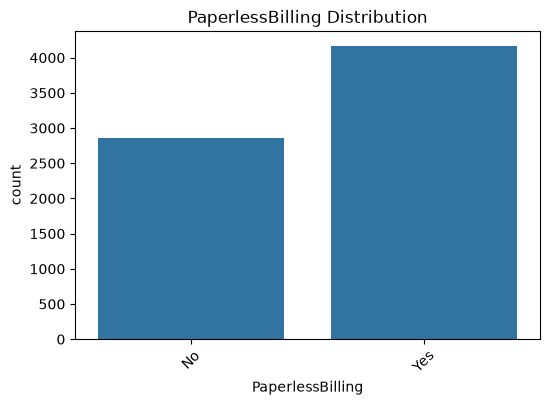

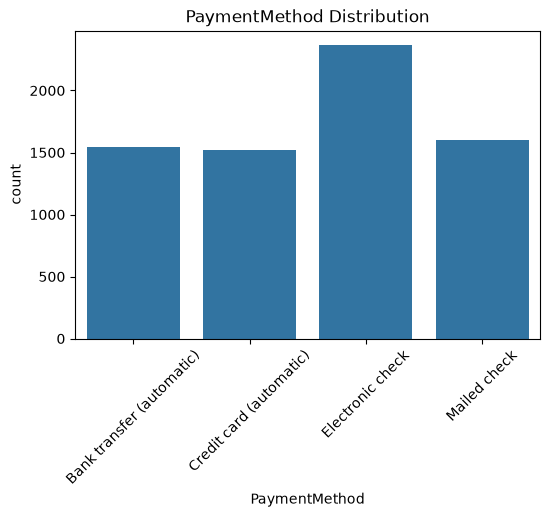

In [150]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

## Multivariate Analysis

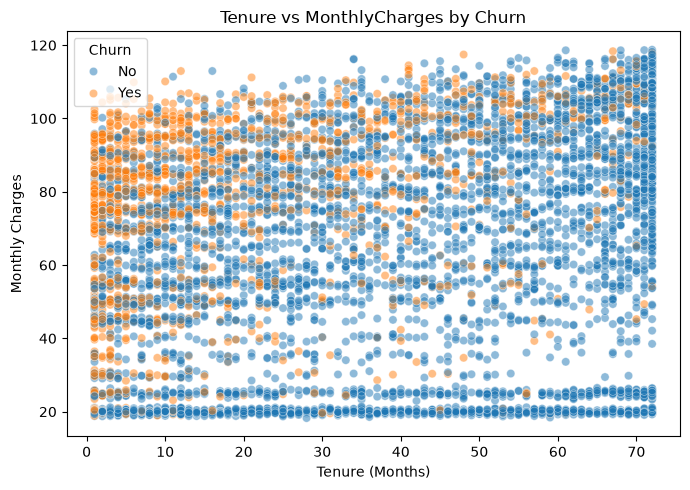

In [151]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.5)
plt.title('Tenure vs MonthlyCharges by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.savefig('../outputs/figures/tenure_monthlycharges_churn.png', dpi=300, bbox_inches='tight')
plt.show()

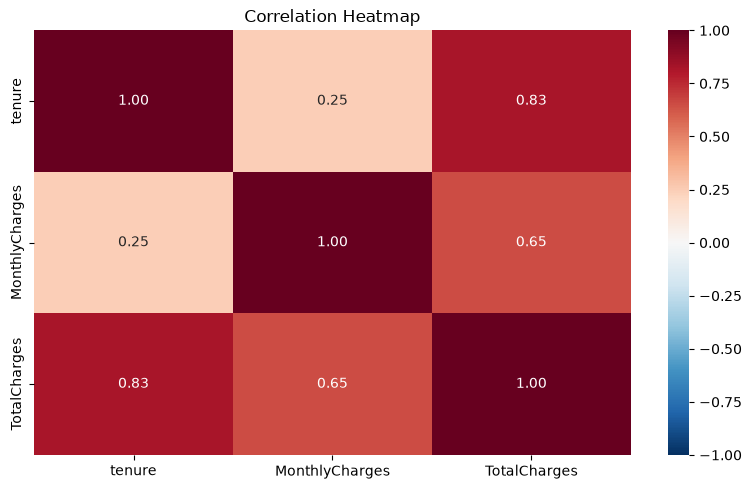

In [152]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

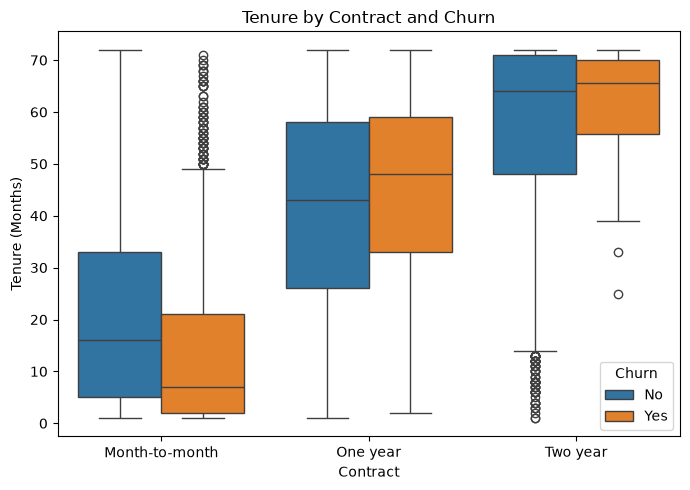

In [153]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Contract', y='tenure', hue='Churn')
plt.title('Tenure by Contract and Churn')
plt.xlabel('Contract')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.savefig('../outputs/figures/tenure_contract_churn.png', dpi=300, bbox_inches='tight')
plt.show()

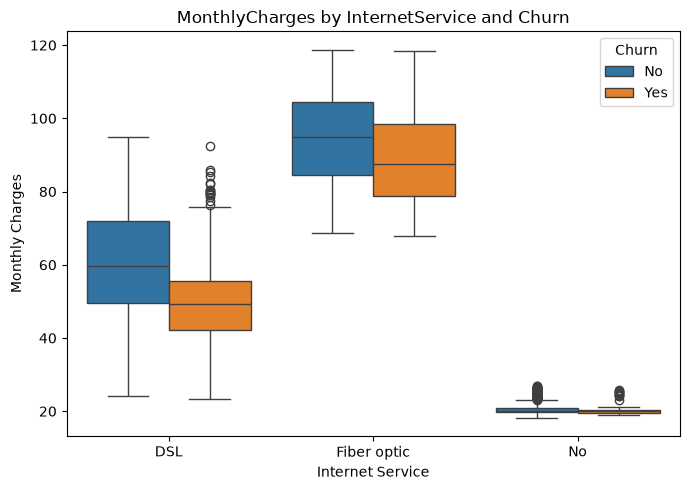

In [154]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', hue='Churn')
plt.title('MonthlyCharges by InternetService and Churn')
plt.xlabel('Internet Service')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.savefig('../outputs/figures/monthlycharges_internetservice_churn.png', dpi=300, bbox_inches='tight')
plt.show()

## Target Analysis

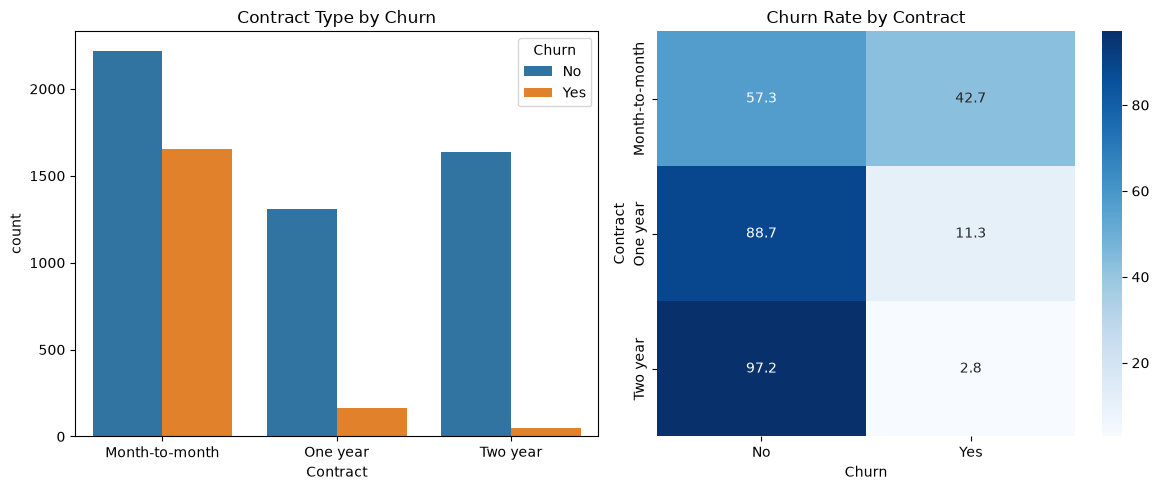

In [155]:
churn_rate = pd.crosstab(df['Contract'], df['Churn'],normalize='index') * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Contract Type by Churn')
sns.heatmap(churn_rate, annot=True, fmt='.1f',cmap='Blues', ax=axes[1])
axes[1].set_title('Churn Rate by Contract')
plt.tight_layout()
plt.savefig('../outputs/figures/contract_churn.png', dpi=300, bbox_inches='tight')
plt.show()

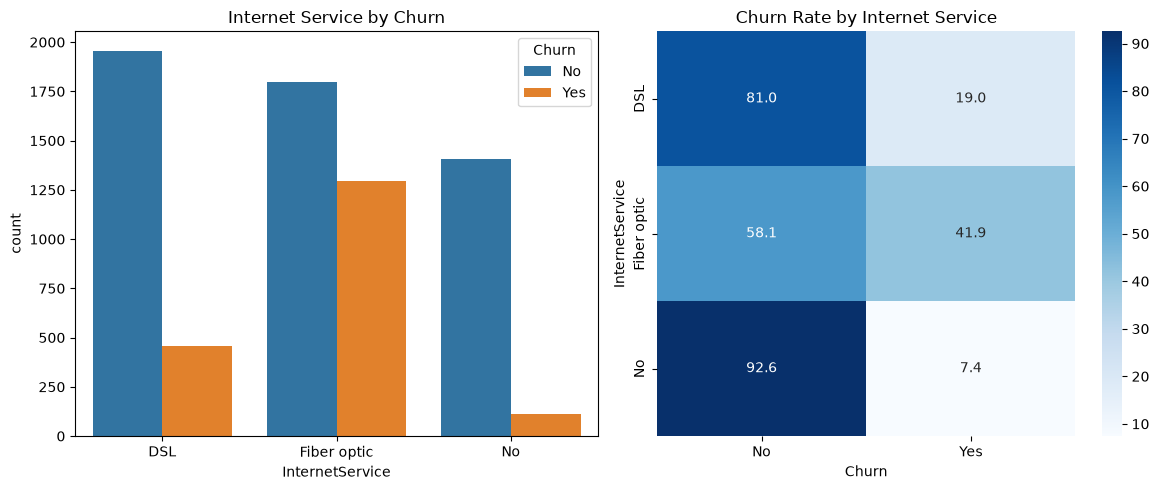

In [156]:
churn_rate = pd.crosstab(df['InternetService'], df['Churn'],normalize='index') * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0])
axes[0].set_title('Internet Service by Churn')
sns.heatmap(churn_rate, annot=True, fmt='.1f',cmap='Blues', ax=axes[1])
axes[1].set_title('Churn Rate by Internet Service')
plt.tight_layout()
plt.savefig('../outputs/figures/internetservice_churn.png', dpi=300, bbox_inches='tight')
plt.show()

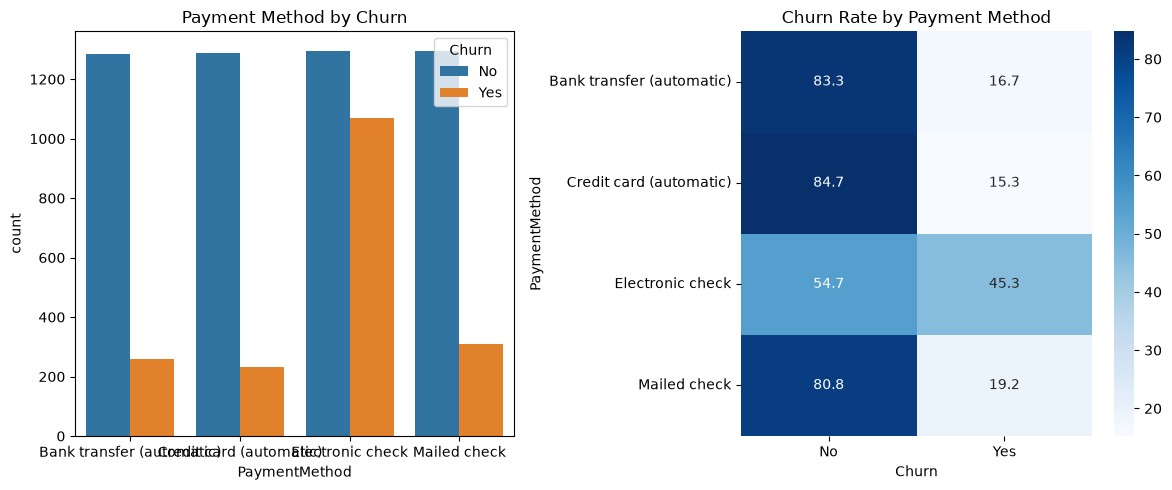

In [157]:
churn_rate = pd.crosstab(df['PaymentMethod'], df['Churn'],normalize='index') * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0])
axes[0].set_title('Payment Method by Churn')
sns.heatmap(churn_rate, annot=True, fmt='.1f',cmap='Blues', ax=axes[1])
axes[1].set_title('Churn Rate by Payment Method')
plt.tight_layout()
plt.savefig('../outputs/figures/paymentmethod_churn.png', dpi=300, bbox_inches='tight')
plt.show()

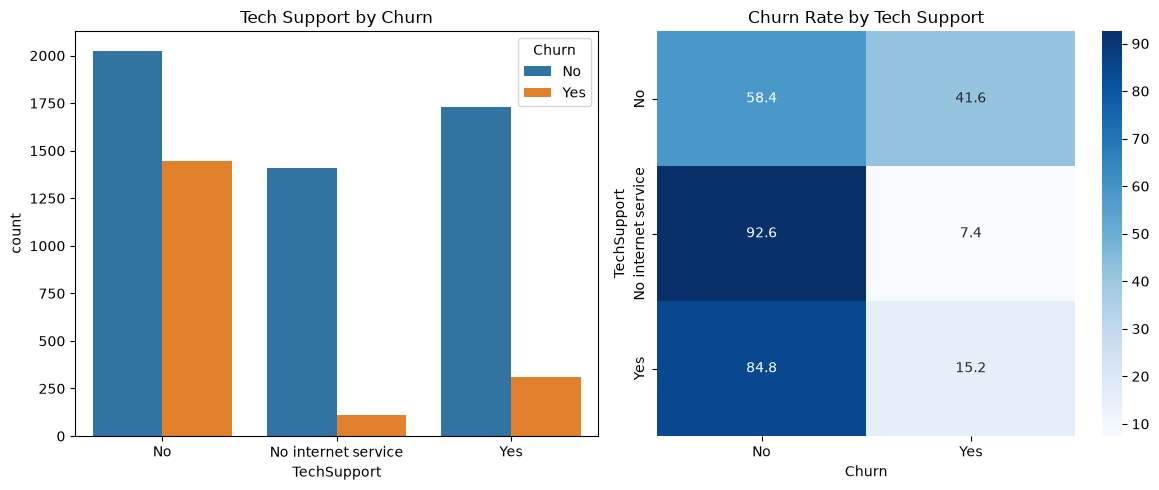

In [158]:
churn_rate = pd.crosstab(df['TechSupport'], df['Churn'],normalize='index') * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[0])
axes[0].set_title('Tech Support by Churn')
sns.heatmap(churn_rate, annot=True, fmt='.1f',cmap='Blues', ax=axes[1])
axes[1].set_title('Churn Rate by Tech Support')
plt.tight_layout()
plt.savefig('../outputs/figures/techsupport_churn.png', dpi=300, bbox_inches='tight')
plt.show()

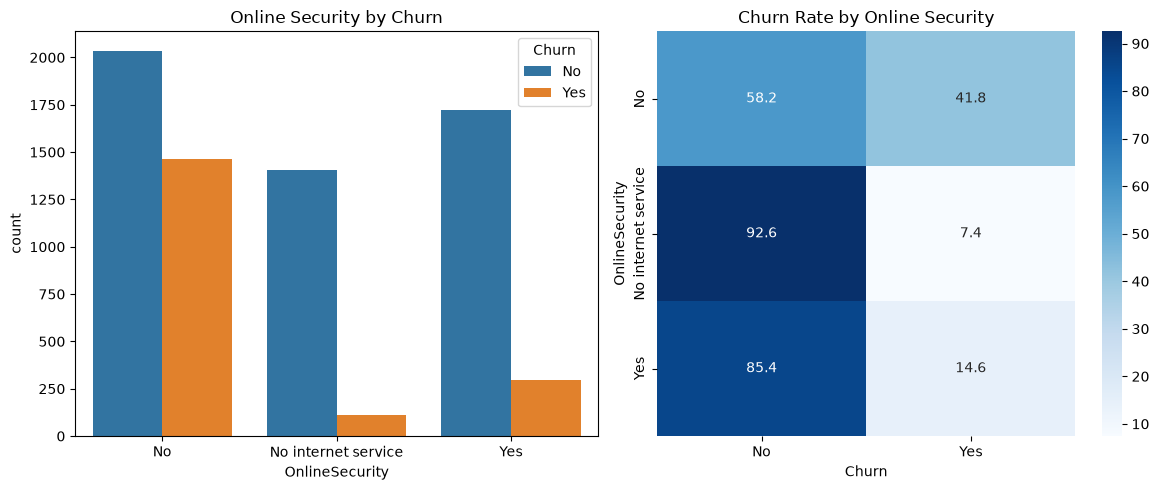

In [159]:
churn_rate = pd.crosstab(df['OnlineSecurity'], df['Churn'],normalize='index') * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='OnlineSecurity', hue='Churn', ax=axes[0])
axes[0].set_title('Online Security by Churn')
sns.heatmap(churn_rate, annot=True, fmt='.1f',cmap='Blues', ax=axes[1])
axes[1].set_title('Churn Rate by Online Security')
plt.tight_layout()
plt.savefig('../outputs/figures/onlinesecurity_churn.png', dpi=300, bbox_inches='tight')
plt.show()

## Interaction Analysis

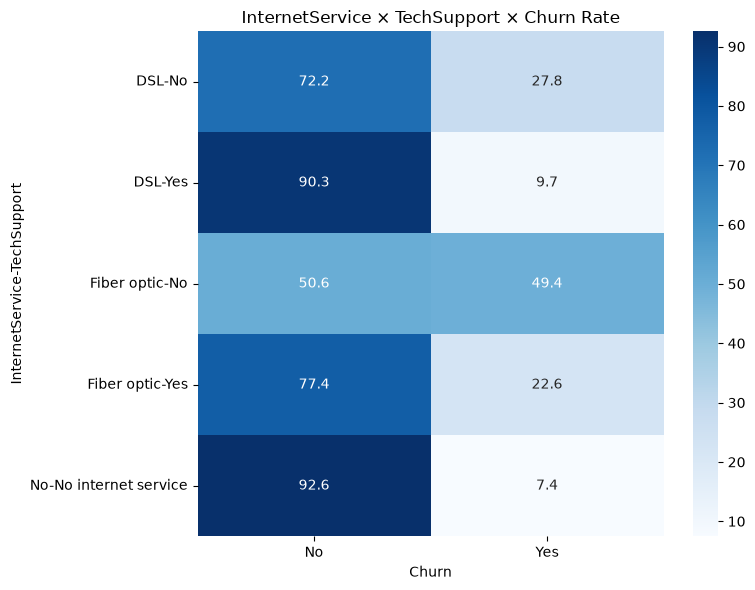

In [160]:
churn_rate = pd.crosstab([df['InternetService'], df['TechSupport']], df['Churn'],normalize='index') * 100
plt.figure(figsize=(8, 6))
sns.heatmap(churn_rate, annot=True, fmt='.1f', cmap='Blues')
plt.title('InternetService × TechSupport × Churn Rate')
plt.tight_layout()
plt.savefig('../outputs/figures/internetservice_techsupport_churn.png', dpi=300, bbox_inches='tight')
plt.show()

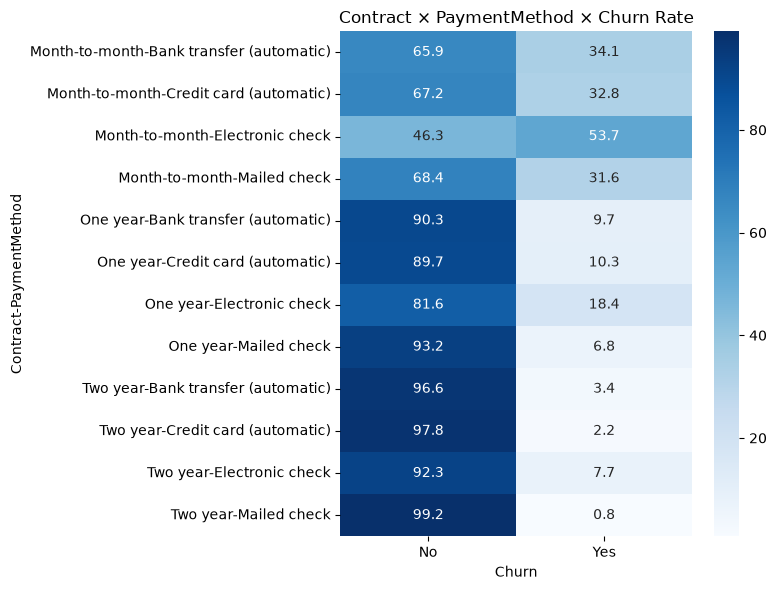

In [161]:
churn_rate = pd.crosstab([df['Contract'], df['PaymentMethod']], df['Churn'], normalize='index') * 100
plt.figure(figsize=(8, 6))
sns.heatmap(churn_rate, annot=True, fmt='.1f', cmap='Blues')
plt.title('Contract × PaymentMethod × Churn Rate')
plt.tight_layout()
plt.savefig('../outputs/figures/contract_paymentmethod_churn.png', dpi=300, bbox_inches='tight')
plt.show()

## Outlier Detection and Treatment

In [162]:
out_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in out_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {outliers.shape[0]}")


tenure
Lower bound: -60.00
Upper bound: 124.00
Number of outliers: 0

MonthlyCharges
Lower bound: -45.82
Upper bound: 171.27
Number of outliers: 0

TotalCharges
Lower bound: -4688.48
Upper bound: 8884.67
Number of outliers: 0


## Summary

### Data Cleaning

ก่อนเริ่มการวิเคราะห์ ได้ทำการทำความสะอาดข้อมูลดังนี้
- ลบคอลัมน์ `customerID` เนื่องจากเป็นเพียงรหัสระบุตัวลูกค้าและไม่มีประโยชน์ต่อการพยากรณ์การ Churn
- แปลงข้อมูลใน `TotalCharges` เป็นชนิดตัวเลข (`numeric`)
- พบค่า Missing ใน `TotalCharges` จำนวน 11 แถว และลบออกจากชุดข้อมูล
- แปลง `SeniorCitizen` จากค่า 0 และ 1 เป็น No และ Yes เพื่อให้ง่ายต่อการวิเคราะห์
- ตรวจสอบข้อมูลซ้ำ (Duplicate Records) และไม่พบข้อมูลซ้ำที่มีนัยสำคัญ
- ตรวจสอบและปรับประเภทข้อมูลให้เหมาะสมสำหรับการวิเคราะห์
หลังจากทำความสะอาดข้อมูลแล้ว ชุดข้อมูลเหลือทั้งหมด **7,032 รายการ**

### การวิเคราะห์ตัวแปรเป้าหมาย (Churn)
- ลูกค้าส่วนใหญ่ยังคงใช้บริการต่อ (Churn = No)
- ลูกค้าที่ยกเลิกบริการ (Churn = Yes) มีประมาณ 26.6% ของข้อมูลทั้งหมด
- ชุดข้อมูลมีความไม่สมดุลของคลาส (Class Imbalance) ในระดับหนึ่ง แต่ยังสามารถนำไปสร้างโมเดลได้

### การวิเคราะห์ตัวแปรเชิงตัวเลข (Numerical Features)
#### Tenure
- ลูกค้าที่มีอายุการใช้งานสั้นมีแนวโน้ม Churn สูงกว่า
- ลูกค้าที่ใช้งานมานานมีแนวโน้มคงอยู่กับบริษัทมากกว่า
#### MonthlyCharges
- ลูกค้าที่มีค่าใช้จ่ายรายเดือนสูงมีแนวโน้ม Churn สูง
- ลูกค้าที่มีค่าใช้จ่ายรายเดือนต่ำมีแนวโน้มอยู่กับบริษัทต่อ
#### TotalCharges
- มีความสัมพันธ์กับ Tenure และ MonthlyCharges
- ลูกค้าที่มี TotalCharges สูงมักเป็นลูกค้าที่อยู่กับบริษัทมานาน

### การวิเคราะห์ตัวแปรเชิงหมวดหมู่ (Categorical Features)
#### Contract
- ลูกค้าที่ใช้สัญญาแบบ **Month-to-month** มีอัตรา Churn สูงที่สุด
- ลูกค้าที่ใช้สัญญา **One year** และ **Two year** มีแนวโน้ม Churn ต่ำอย่างชัดเจน
#### InternetService
- ลูกค้าที่ใช้บริการ **Fiber optic** มีอัตรา Churn สูงกว่ากลุ่มอื่น
#### PaymentMethod
- ลูกค้าที่ชำระเงินผ่าน **Electronic check** มีแนวโน้ม Churn สูง
#### TechSupport
- ลูกค้าที่ไม่มีบริการ **TechSupport** มีแนวโน้ม Churn สูงกว่า
#### OnlineSecurity
- ลูกค้าที่ไม่มีบริการ **OnlineSecurity** มีแนวโน้ม Churn สูงกว่า


### การวิเคราะห์ความสัมพันธ์ระหว่างตัวแปร (Interaction Analysis)
#### Tenure × MonthlyCharges × Churn
- ลูกค้าใหม่ที่มีค่าใช้จ่ายรายเดือนสูงเป็นกลุ่มที่มีความเสี่ยง Churn สูงที่สุด
#### InternetService × TechSupport × Churn
- ลูกค้าที่ใช้ Fiber optic และไม่มี TechSupport มีแนวโน้ม Churn สูง
#### InternetService × OnlineSecurity × Churn
- ลูกค้าที่ใช้ Fiber optic และไม่มี OnlineSecurity มีแนวโน้ม Churn สูง
#### Contract × PaymentMethod × Churn
- ลูกค้าที่ใช้สัญญา Month-to-month และชำระเงินด้วย Electronic check เป็นกลุ่มเสี่ยงสูงต่อการ Churn

### แนวทางสำหรับ Feature Engineering
จากผลการวิเคราะห์ พบว่าตัวแปรต่อไปนี้มีศักยภาพในการสร้าง Feature ใหม่เพื่อเพิ่มประสิทธิภาพของโมเดล
- `tenure_group`
- `monthlycharge_level`
- `long_term_contract`
- `is_fiber`
- `has_tech_support`
- `has_security`
- `electronic_payment`
- `high_charge_new_customer`
- `fiber_no_support`
- `fiber_no_security`
- `high_risk_customer`

Feature เหล่านี้ถูกเสนอจากรูปแบบและความสัมพันธ์ที่พบในขั้นตอน EDA และควรได้รับการทดสอบเพิ่มเติมในขั้นตอน Feature Engineering และ Model Development ต่อไป